# **Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.preprocessing import MinMaxScaler, minmax_scale
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
from torch.optim.lr_scheduler import LinearLR, CosineAnnealingLR, SequentialLR
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
import zipfile
#from google.colab import drive

In [ ]:
def set_seed_strict(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        
        torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True, warn_only=True)


set_seed_strict(42)

# **Data Loading & Data Preparation**



In [3]:
"""
drive.mount('/content/drive')
zip_path = '/content/drive/MyDrive/datasets_with_visibility.zip'
csv = {}

with zipfile.ZipFile(zip_path, 'r') as z:
    # Get a list of all files in the zip
    all_files = z.namelist()

    # Filter for only CSV files
    csv_files = [f for f in all_files if f.endswith('.csv') and not f.startswith('__MACOSX')]

    for csv_path in csv_files:
        with z.open(csv_path) as f:
            # Use the filename as the key
            file_name = csv_path.split('/')[-1]
            csv[file_name] = pd.read_csv(f)
            print(f"Loaded: {csv_path}")
"""

'\ndrive.mount(\'/content/drive\')\nzip_path = \'/content/drive/MyDrive/datasets_with_visibility.zip\'\ncsv = {}\n\nwith zipfile.ZipFile(zip_path, \'r\') as z:\n    # Get a list of all files in the zip\n    all_files = z.namelist()\n\n    # Filter for only CSV files\n    csv_files = [f for f in all_files if f.endswith(\'.csv\') and not f.startswith(\'__MACOSX\')]\n\n    for csv_path in csv_files:\n        with z.open(csv_path) as f:\n            # Use the filename as the key\n            file_name = csv_path.split(\'/\')[-1]\n            csv[file_name] = pd.read_csv(f)\n            print(f"Loaded: {csv_path}")\n'

## **Load Datasets**

In [4]:
"""
train_df = csv['keypoint_train_data.csv']
valid_df = csv['keypoint_valid_data.csv']
test_df = csv['keypoint_test_data.csv']
"""

train_df = pd.read_csv('keypoint_train_data.csv')
valid_df = pd.read_csv('keypoint_valid_data.csv')
test_df = pd.read_csv('keypoint_test_data.csv')

##**Shift [cat_id] from 1:2 to 0:1**

In [5]:
train_df['cat_id'] = train_df['cat_id'] - 1
valid_df['cat_id'] = valid_df['cat_id'] - 1
test_df['cat_id'] = test_df['cat_id'] - 1

train_df.head()

,image_id,cat_id,nose_x,nose_y,nose_v,left_eye_x,left_eye_y,left_eye_v,right_eye_x,right_eye_y,...,left_knee_v,right_knee_x,right_knee_y,right_knee_v,left_ankle_x,left_ankle_y,left_ankle_v,right_ankle_x,right_ankle_y,right_ankle_v
0,0,0,381.166412,125.746658,1.0,381.166412,114.563187,1.0,373.181763,114.563187,...,1.0,504.129974,394.948792,1.0,526.487000,553.115051,1.0,527.285461,553.115051,1.0
1,1,1,368.703186,200.296249,1.0,373.500092,186.699783,1.0,371.901123,187.499557,...,1.0,349.515381,372.251770,1.0,328.728607,556.204163,1.0,362.307220,524.212402,1.0
2,2,1,254.824997,367.375610,1.0,227.677002,378.566132,1.0,227.677002,378.566132,...,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0
3,3,1,423.618744,145.820709,1.0,431.610840,129.045349,1.0,426.815582,129.045349,...,1.0,298.142303,403.841614,1.0,148.689423,582.778748,1.0,256.583221,536.446777,1.0
4,4,1,241.430283,215.023224,1.0,243.826614,201.425888,1.0,242.229050,203.025558,...,1.0,223.857300,387.789368,1.0,203.089233,563.754883,1.0,239.033966,539.759583,1.0


##**Data Normalization**

In [6]:
def minmax_normalise(df, variations: str, scaler=None, is_train: bool=True):

    df_normalized = df.copy()

    coord_cols = df_normalized.columns.drop(['image_id', 'cat_id'])

    ####################################
    # Generated from Gemini
    ####################################
    visibility_cols = [col for col in coord_cols if col.endswith('_v')]
    xy_cols = [col for col in coord_cols if not col.endswith('_v')]
    ####################################
    # End
    ####################################

    for visibility_col in visibility_cols:
        col_name = visibility_col.replace('_v', '')
        X_col = f"{col_name}_x"
        y_col = f"{col_name}_y"

        # Mask here contains boolean of each row whether if visibility_col[i] is 0.0
        mask = df_normalized[visibility_col] == 0.0
        df_normalized.loc[mask, [X_col, y_col]] = np.nan

    if variations=="col_wise":
        print("Using MinMaxScaler")
        if is_train:
            scaler = MinMaxScaler()
            df_normalized[xy_cols] = scaler.fit_transform(df_normalized[xy_cols])

        else:
            if scaler is None:
                print("No scaler given!")

            df_normalized[xy_cols] = scaler.transform(df_normalized[xy_cols])

    elif variations=="row_wise":
        print("Using minmax_scale")
        scaled_array = minmax_scale(df_normalized[xy_cols], axis=1)
        df_normalized[xy_cols] = scaled_array

    df_normalized[xy_cols] = df_normalized[xy_cols].fillna(0.0)

    if variations=="col_wise" and is_train:
        return df_normalized, scaler
    else:
        return df_normalized

In [7]:
def manual_normalisation(df):
    """
    Wraps the PyTorch normalize_coco_posture function to work on a Pandas DataFrame.
    """
    df_normalized = df.copy()
    coord_cols = df_normalized.columns.drop(['image_id', 'cat_id'])

    for index, row in df_normalized.iterrows():
        raw_coords = row[coord_cols].values.astype(np.float32)

        tensor_coords = torch.tensor(raw_coords).view(17, 3)

        normalized_tensor = normalize_coco_posture_safe(tensor_coords)

        flat_normalized_coords = normalized_tensor.view(-1).numpy()

        df_normalized.loc[index, coord_cols] = flat_normalized_coords

    return df_normalized

def normalize_coco_posture_safe(pos_tensor):
    """
    Safely normalizes a [17, 3] COCO keypoint tensor using the Visibility flag.
    """
    coords = pos_tensor[:, :2].clone() # [17, 2]
    vis = pos_tensor[:, 2].clone()     # [17]

    valid_mask = vis > 0.0

    if not valid_mask.any():
        return pos_tensor

    l_hip_valid = valid_mask[11].item()
    r_hip_valid = valid_mask[12].item()

    if l_hip_valid and r_hip_valid:
        root = (coords[11] + coords[12]) / 2.0
    elif l_hip_valid:
        root = coords[11]  
    elif r_hip_valid:
        root = coords[12]  
    else:
        l_sho_valid = valid_mask[5].item()
        r_sho_valid = valid_mask[6].item()
        if l_sho_valid and r_sho_valid:
            root = (coords[5] + coords[6]) / 2.0
        else:
            root = torch.tensor([0.0, 0.0], device=coords.device)

    coords[valid_mask] = coords[valid_mask] - root

    # 4. Aspect-Preserving Scale ONLY on valid points
    min_vals = coords[valid_mask].min(dim=0)[0]
    max_vals = coords[valid_mask].max(dim=0)[0]
    ranges = max_vals - min_vals
    global_scale = ranges.max()

    # Scale valid points. Add epsilon to prevent division by zero
    coords[valid_mask] = coords[valid_mask] / (global_scale + 1e-6)

    final_tensor = torch.cat([coords, vis.unsqueeze(1)], dim=1)

    return final_tensor

In [8]:
def normalise(df, is_train:bool, type: str=None, scaler=None, variation: str=None):
    if type == "manual":
        df_normalized = manual_normalisation(df)
        return df_normalized

    elif type == "auto" and variation in ["row_wise", "col_wise"]:

        if is_train and variation == "col_wise":
            df_normalized, scaler = minmax_normalise(df=df, variations=variation, scaler=scaler, is_train=is_train)
            return df_normalized, scaler

        else:
            df_normalized = minmax_normalise(df=df, variations=variation, scaler=scaler, is_train=is_train)
            return df_normalized

    else:
        print("Unknown type or variation given.")
        raise ValueError("Normalization failed due to invalid arguments.")

In [9]:

"""
# manual normalization
train_df_norm = normalise(train_df, is_train=False, type="manual")
valid_df_norm = normalise(valid_df, is_train=False, type="manual")
test_df_norm = normalise(test_df, is_train=False, type="manual")
"""

# MinMaxScaler
train_df_norm, fitted_scaler = normalise(df=train_df, is_train=True, type="auto", variation="col_wise")
valid_df_norm = normalise(df=valid_df, is_train=False, type="auto", scaler=fitted_scaler, variation="col_wise")
test_df_norm = normalise(df=test_df, is_train=False, type="auto", scaler=fitted_scaler, variation="col_wise")


# minmax_scale
# train_df_norm = normalise(df=train_df, is_train=False, type="auto", variation="row_wise")
# valid_df_norm = normalise(df=valid_df, is_train=False, type="auto", variation="row_wise")
# test_df_norm = normalise(df=test_df, is_train=False, type="auto", variation="row_wise")


Using MinMaxScaler
Using MinMaxScaler
Using MinMaxScaler


## **Dataset Class**

In [10]:
class KeypointDataset(Dataset):
  def __init__(self, df):
    X_np = df.drop(['image_id', 'cat_id'], axis =1).values
    y_np = df['cat_id'].values

    # Reshape from (N, 34) to (N, 17, 3)
    N = X_np.shape[0]
    X_reshape = X_np.reshape(N, 17, 3)

    X_transpose = np.transpose(X_reshape, (0, 2, 1))

    # Convert to tensors
    self.X = torch.tensor(X_transpose, dtype=torch.float32)
    self.y = torch.tensor(y_np,dtype=torch.float32).unsqueeze(1)

  def __len__(self):
    return len(self.X)

  def __getitem__(self, idx):
    return self.X[idx], self.y[idx]

In [11]:
train_dataset = KeypointDataset(train_df_norm)
valid_dataset = KeypointDataset(valid_df_norm)
test_dataset = KeypointDataset(test_df_norm)

##**Batch Loading with DataLoader**

In [12]:
BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

In [13]:
X_batch, y_batch = next(iter(train_loader))
print("Batch X shape:", X_batch.shape)
print("Batch y shape:", y_batch.shape)

Batch X shape: torch.Size([64, 3, 17])
Batch y shape: torch.Size([64, 1])


#**Model Class**

In [14]:
class CNN1d(nn.Module):
  def __init__(self):
    super().__init__()

    self.conv1 = nn.Conv1d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
    self.bn1 = nn.BatchNorm1d(32)
    self.pool1 = nn.MaxPool1d(kernel_size=2)

    ####################################
    # Generated from Gemini
    ####################################
    self.spatial_dropout1 = nn.Dropout1d(p=0.2)
    ####################################
    # End
    ####################################

    self.conv2 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
    self.bn2 = nn.BatchNorm1d(64)
    self.pool2 = nn.MaxPool1d(kernel_size=2)

    ####################################
    # Generated from Gemini
    ####################################
    self.spatial_dropout2 = nn.Dropout1d(p=0.2)

    self.global_avg_pool = nn.AdaptiveAvgPool1d(1)
    ####################################
    # End
    ####################################

    self.fc1 = nn.Linear(64, 32)
    self.dropout = nn.Dropout(p=0.6)
    self.fc2 = nn.Linear(32, 1)

  def forward(self, x):
    x = self.conv1(x)
    x = self.bn1(x)
    x = F.relu(x)
    x = self.pool1(x)

    x = self.spatial_dropout1(x)

    x = self.conv2(x)
    x = self.bn2(x)
    x = F.relu(x)
    x = self.pool2(x)

    x = self.spatial_dropout2(x)

    x = self.global_avg_pool(x)
    x = torch.flatten(x, 1)

    x = self.fc1(x)
    x = F.relu(x)
    x = self.dropout(x)

    x = self.fc2(x)

    return x

In [15]:
model = CNN1d()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
print(model)

CNN1d(
  (conv1): Conv1d(3, 32, kernel_size=(3,), stride=(1,), padding=(1,))
  (bn1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (spatial_dropout1): Dropout1d(p=0.2, inplace=False)
  (conv2): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(1,))
  (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (spatial_dropout2): Dropout1d(p=0.2, inplace=False)
  (global_avg_pool): AdaptiveAvgPool1d(output_size=1)
  (fc1): Linear(in_features=64, out_features=32, bias=True)
  (dropout): Dropout(p=0.6, inplace=False)
  (fc2): Linear(in_features=32, out_features=1, bias=True)
)


In [16]:
def calculate_accuracy(y_pred, y_true):
    # Apply sigmoid to the raw logits to get probabilities
    probabilities = torch.sigmoid(y_pred)
    predicted_classes = torch.round(probabilities)
    # Count how many match the true labels
    correct = (predicted_classes == y_true).sum().float()
    # Calculate percentage
    return correct / y_true.shape[0]

#**Training Loop**

In [17]:
epochs = 200
warmup_epochs = 5

best_val_loss = float('inf')
patience = 30
patience_count = 0
checkpoint_path = "1D-CNN.pth"

train_losses = []
train_accs = []
valid_losses = []
valid_accs = []

loss_function = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001)
warmup_scheduler = LinearLR(optimizer, start_factor=0.1, total_iters=warmup_epochs)
decay_scheduler = CosineAnnealingLR(optimizer, T_max=(epochs - warmup_epochs), eta_min=1e-6)

scheduler = SequentialLR(
    optimizer,
    schedulers=[warmup_scheduler, decay_scheduler],
    milestones=[warmup_epochs]
)

for epoch in range(epochs):
  model.train()

  train_loss = 0.0
  train_acc = 0.0

  for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()

        predictions = model(X_batch)

        loss = loss_function(predictions, y_batch)

        loss.backward()

        optimizer.step()

        train_loss += loss.item()
        train_acc += calculate_accuracy(predictions, y_batch).item()

  scheduler.step()

  avg_train_loss = train_loss / len(train_loader)
  avg_train_acc = train_acc / len(train_loader)

  model.eval()
  valid_loss = 0.0
  valid_acc = 0.0

  with torch.no_grad():
      for X_batch, y_batch in valid_loader:
          X_batch, y_batch = X_batch.to(device), y_batch.to(device)

          predictions = model(X_batch)
          loss = loss_function(predictions, y_batch)

          valid_loss += loss.item()
          valid_acc += calculate_accuracy(predictions, y_batch).item()

  avg_valid_loss = valid_loss / len(valid_loader)
  avg_valid_acc = valid_acc / len(valid_loader)

  train_losses.append(avg_train_loss)
  train_accs.append(avg_train_acc)
  valid_losses.append(avg_valid_loss)
  valid_accs.append(avg_valid_acc)

  print(f"Epoch [{epoch+1:02d}/{epochs}] "
          f"| Train Loss: {avg_train_loss:.4f} | Train Acc: {avg_train_acc*100:.2f}% "
          f"| Valid Loss: {avg_valid_loss:.4f} | Valid Acc: {avg_valid_acc*100:.2f}%")

  if avg_valid_loss < best_val_loss:
      print(f"Valid loss improved. Saving checkpoint to {checkpoint_path}")
      best_val_loss = avg_valid_loss
      patience_counter = 0
      torch.save(model.state_dict(), checkpoint_path)
  else:
      patience_counter += 1
      print(f"Patience: {patience_counter}/{patience}")
      if patience_counter >= patience:
          print("Early Stopping triggered")
          break

print("Training Complete.")

Epoch [01/200] | Train Loss: 0.7049 | Train Acc: 48.80% | Valid Loss: 0.6994 | Valid Acc: 48.49%
Valid loss improved. Saving checkpoint to 1D-CNN.pth
Epoch [02/200] | Train Loss: 0.6974 | Train Acc: 50.23% | Valid Loss: 0.6921 | Valid Acc: 48.49%
Valid loss improved. Saving checkpoint to 1D-CNN.pth
Epoch [03/200] | Train Loss: 0.6887 | Train Acc: 54.62% | Valid Loss: 0.6786 | Valid Acc: 63.10%
Valid loss improved. Saving checkpoint to 1D-CNN.pth
Epoch [04/200] | Train Loss: 0.6750 | Train Acc: 58.09% | Valid Loss: 0.6654 | Valid Acc: 67.53%
Valid loss improved. Saving checkpoint to 1D-CNN.pth
Epoch [05/200] | Train Loss: 0.6622 | Train Acc: 61.69% | Valid Loss: 0.6517 | Valid Acc: 67.53%
Valid loss improved. Saving checkpoint to 1D-CNN.pth
Epoch [06/200] | Train Loss: 0.6640 | Train Acc: 61.43% | Valid Loss: 0.6336 | Valid Acc: 68.06%
Valid loss improved. Saving checkpoint to 1D-CNN.pth
Epoch [07/200] | Train Loss: 0.6563 | Train Acc: 63.38% | Valid Loss: 0.6233 | Valid Acc: 70.14%
Val

#**Model Loss & Accuracy**

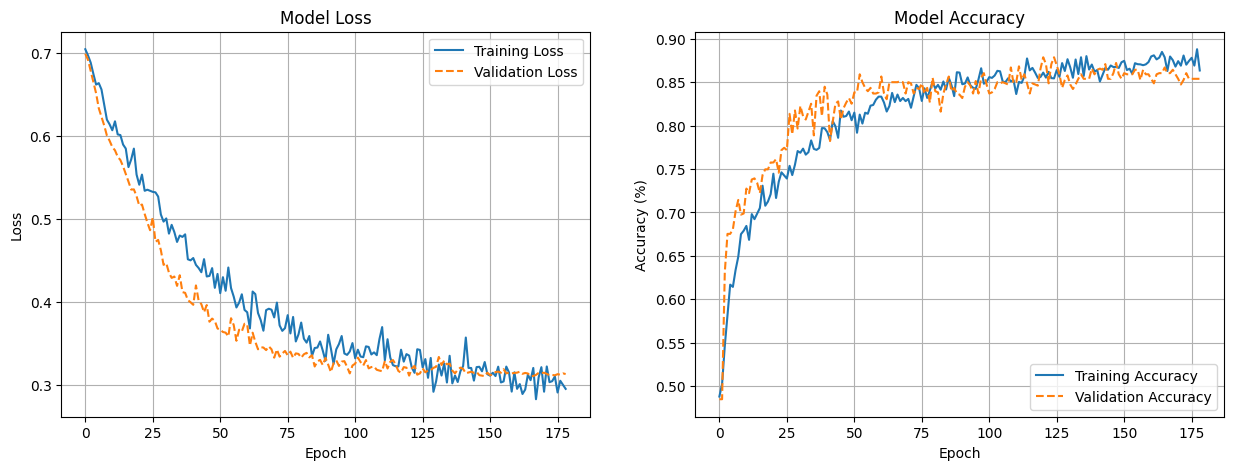

In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(train_losses, label='Training Loss')
ax1.plot(valid_losses, label='Validation Loss', linestyle='--')
ax1.set_title('Model Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

ax2.plot(train_accs, label='Training Accuracy')
ax2.plot(valid_accs, label='Validation Accuracy', linestyle='--')
ax2.set_title('Model Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(True)

plt.show()

#**Classification Report - Test Set**

In [ ]:
model.load_state_dict(torch.load("1D-CNN.pth"))
model.eval()
print("Best model loaded")

final_preds = []
final_true = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        out = model(X_batch)
        probs = torch.sigmoid(out)
        preds = (probs > 0.5).float()

        final_preds.extend(preds.cpu().numpy())
        final_true.extend(y_batch.cpu().numpy())

print(classification_report(final_true, final_preds, target_names=["Good Posture", "Bad Posture"], zero_division=0))

Best model loaded
[array([1.], dtype=float32), array([0.], dtype=float32), array([1.], dtype=float32), array([0.], dtype=float32), array([0.], dtype=float32), array([1.], dtype=float32), array([1.], dtype=float32), array([0.], dtype=float32), array([0.], dtype=float32), array([1.], dtype=float32), array([0.], dtype=float32), array([1.], dtype=float32), array([0.], dtype=float32), array([1.], dtype=float32), array([0.], dtype=float32), array([0.], dtype=float32), array([1.], dtype=float32), array([0.], dtype=float32), array([0.], dtype=float32), array([1.], dtype=float32), array([1.], dtype=float32), array([0.], dtype=float32), array([1.], dtype=float32), array([0.], dtype=float32), array([1.], dtype=float32), array([1.], dtype=float32), array([0.], dtype=float32), array([1.], dtype=float32), array([0.], dtype=float32), array([1.], dtype=float32), array([0.], dtype=float32), array([0.], dtype=float32), array([1.], dtype=float32), array([1.], dtype=float32), array([1.], dtype=float32), a